# **King County House Data**

**Bài toán:** Cho một tập dữ liệu về nhà ở với các đặc trưng như diện tích (square footage), số phòng ngủ, vị trí,... hãy dự đoán giá nhà (`price`) cho những ngôi nhà ở quận King, Washington, Hoa Kỳ.

**Mục tiêu:** Dự đoán giá nhà bằng OLS để hiểu cách mô hình tuyến tính hoạt động ở cấp độ toán học, sử dụng dữ liệu đã tiền xử lý từ `Pre_housing.ipynb`.


## Model: Linear Regression — OLS

**Normal Equation:**
$$\theta = (\tilde{X}^T \tilde{X})^{-1} \tilde{X}^T y \quad \text{với } \tilde{X} = [\mathbf{1} \;|\; X]$$

**Mục lục:**

| # | Phase | Nội dung |
|---|-------|----------|
| 1 | [Chuẩn bị dữ liệu](#Phase-1-—-Chuẩn-bị-dữ-liệu) | Load dữ liệu, tách feature và target |
| 2 | [Kiểm tra ma trận](#Phase-2-—-Kiểm-tra-khả-nghịch-ma-trận) | Kiểm tra tính khả nghịch ma trận trên tập train |
| 3 | [Huấn luyện & dự đoán](#Phase-3-—-Xây-dựng-mô-hình) | Xây dựng class Linear Regression, huấn luyện và dự đoán |
| 4 | [Đánh giá](#Phase-4-—-Đánh-giá-mô-hình) | Tính metric trên 3 tập |
| 5 | [Trực quan hoá](#Phase-5-—-Trực-quan-hoá) | Vẽ biểu đồ đánh giá trên tập test |

## [Phase 1 — Chuẩn bị dữ liệu]
### Dữ liệu

**Nguồn:** `kc_house_data_NaN.csv`.

**Preprocessing (áp dụng khi load):**
- ` y_train_log = log1p(price)` — target huấn luyện
- ` y_train_price, y_val_price, y_test_price`  — giá gốc USD, chỉ dùng đánh giá 
- `X` = feature đã scale, **loại** `price_log` tránh dataleak.

**Tổng quan các tập dữ liệu (70:15:15):**

| Tập | File | Số mẫu |
|-----|------|--------|
| Train | `X_train.csv`, `y_train.csv` | 15,128 |
| Validation | `X_val.csv`, `y_val.csv` | 3,243 |
| Test | `X_test.csv`, `y_test.csv` | 3,242 |



In [178]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [179]:
# LOAD DATASET — 3 tập train / validation / test

DROP_COLS = ['price_log']  # X không chứa price_log (đó là target)

X_train_df = pd.read_csv('X_train.csv').drop(columns=DROP_COLS)
X_val_df   = pd.read_csv('X_val.csv').drop(columns=DROP_COLS)
X_test_df  = pd.read_csv('X_test.csv').drop(columns=DROP_COLS)

feature_names = list(X_train_df.columns)

X_train = X_train_df.values.astype(float)
X_val   = X_val_df.values.astype(float)
X_test  = X_test_df.values.astype(float)

# Giá gốc (USD) — dùng cho đánh giá & biểu đồ
y_train_price = pd.read_csv('y_train.csv')['price'].values.astype(float)
y_val_price   = pd.read_csv('y_val.csv')['price'].values.astype(float)
y_test_price  = pd.read_csv('y_test.csv')['price'].values.astype(float)

# Target huấn luyện: price_log = log1p(price)
y_train_log = np.log1p(y_train_price)

print(f"Số feature trong X: {len(feature_names)} (đã loại price_log)")
print(f"X_train: {X_train.shape}, y_train_log: {y_train_log.shape}")
print(f"X_val:   {X_val.shape},   y_val_price:   {y_val_price.shape}")
print(f"X_test:  {X_test.shape},  y_test_price: {y_test_price.shape}")
print(f"\nMissing — Train: {np.isnan(X_train).sum()}, Val: {np.isnan(X_val).sum()}, Test: {np.isnan(X_test).sum()}")


Số feature trong X: 22 (đã loại price_log)
X_train: (15128, 22), y_train_log: (15128,)
X_val:   (3243, 22),   y_val_price:   (3243,)
X_test:  (3242, 22),  y_test_price: (3242,)

Missing — Train: 0, Val: 0, Test: 0


## [Phase 2 — Kiểm tra tính khả nghịch ma trận]

Kiểm tra tính khả nghịch và độ ổn định của ma trận $\tilde{X}^T \tilde{X}$ **trên tập Train** trước khi giải Normal Equation.


In [180]:
# Kiểm tra tính suy biến ma trận trên tập Train
ones = np.ones((X_train.shape[0], 1))
X_aug = np.hstack([ones, X_train])

XTX = X_aug.T @ X_aug

det  = np.linalg.det(XTX)
rank = np.linalg.matrix_rank(XTX)
shape = XTX.shape
cond = np.linalg.cond(XTX)

print("=" * 50)
print("XTX Matrix Diagnostics (Train set)")
print("=" * 50)
print(f"Determinant      : {det:.4e}")
print(f"Matrix Rank      : {rank}")
print(f"Matrix Shape     : {shape}")
print(f"Condition Number : {cond:.4e}")


XTX Matrix Diagnostics (Train set)
Determinant      : 1.7626e+89
Matrix Rank      : 23
Matrix Shape     : (23, 23)
Condition Number : 4.3288e+02


**Nhận xét:**

- Ma trận có **23×23** (1 bias + 22 feature), rank đầy đủ → không suy biến hoàn toàn.
- Condition Number ~ $10^2$ — ổn định số học; dùng `numpy.linalg.lstsq()` thay cho `inv()`.


## [Phase 3 — Xây dựng mô hình]

### Linear Regression (OLS)

1. **Train:** `model.fit(X_train, y_train_log)`
2. **Predict:** Ra `pred_log` trên 3 tập
3. **Inverse:** `np.expm1(pred_log)` → `price` gốc (ngược của `log1p`)
4. **Đánh giá:** So sánh với `y_train_price, y_val_price, y_test_price  `


In [181]:
class LinearRegressionOLS:
    """
    Linear Regression solved via Ordinary Least Squares (Normal Equation).
    Implemented with lstsq for numerical stability.
    """

    def __init__(self):
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        ones = np.ones((n_samples, 1))
        X_aug = np.hstack([ones, X])

        theta, _, _, _ = np.linalg.lstsq(X_aug, y, rcond=None)

        self.bias    = theta[0]
        self.weights = theta[1:]

        print("OLS fit complete!")
        print(f"Bias = {self.bias:.6f}")
        print(f"Weights: shape={self.weights.shape}")

    def predict(self, X):
        return X @ self.weights + self.bias


### 3.1 — Huấn luyện trên `price_log` (tập Train)


In [182]:
# Train trên price_log
model = LinearRegressionOLS()
model.fit(X_train, y_train_log)

OLS fit complete!
Bias = 13.047021
Weights: shape=(22,)


### 3.2 — Dự đoán `price_log` trên Train / Val / Test


In [183]:
# 2. Dự đoán ra price_log
train_pred_price_log = model.predict(X_train)
val_pred_price_log   = model.predict(X_val)
test_pred_price_log  = model.predict(X_test)

print(f"Train pred_price_log: {train_pred_price_log.shape}")
print(f"Val pred_price_log:   {val_pred_price_log.shape}")
print(f"Test pred_price_log:  {test_pred_price_log.shape}")


Train pred_price_log: (15128,)
Val pred_price_log:   (3243,)
Test pred_price_log:  (3242,)


### 3.3 — Chuyển ngược `price_log` về `price` gốc

`expm1()` là phép ngược của `log1p()` dùng trong tiền xử lý:

$$\text{price} = \mathrm{expm1}(\text{price\_log}) = e^{\text{price\_log}} - 1$$


In [184]:
# Inverse: expm1(pred_log) → price gốc (USD)
train_pred_price = np.expm1(train_pred_price_log)
val_pred_price   = np.expm1(val_pred_price_log)
test_pred_price  = np.expm1(test_pred_price_log)

## [Phase 4 — Đánh giá mô hình]

In [185]:
# Evaluation Metrics

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def format_metric_table(df):
    """Format MSE/RMSE/MAE có dấu phẩy; R² giữ 4 chữ số thập phân."""
    display_df = df.copy()
    for col in ["Train", "Val", "Test"]:
        formatted = []
        for metric, val in zip(display_df["Metric"], display_df[col]):
            if metric == "R²":
                formatted.append(f"{val:.4f}")
            else:
                formatted.append(f"{val:,.0f}")
        display_df[col] = formatted  # cột chuỗi — không ghi đè results_ols gốc
    return display_df


### 4.1 — Metrics trên `price` gốc (Train / Val / Test)


In [186]:
# Metrics OLS trên price gốc
results_ols = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "R²"],
    "Train": [
        mse(y_train_price, train_pred_price),
        rmse(y_train_price, train_pred_price),
        mae(y_train_price, train_pred_price),
        r2_score(y_train_price, train_pred_price),
    ],
    "Val": [
        mse(y_val_price, val_pred_price),
        rmse(y_val_price, val_pred_price),
        mae(y_val_price, val_pred_price),
        r2_score(y_val_price, val_pred_price),
    ],
    "Test": [
        mse(y_test_price, test_pred_price),
        rmse(y_test_price, test_pred_price),
        mae(y_test_price, test_pred_price),
        r2_score(y_test_price, test_pred_price),
    ],
})

results_ols

print("\n=== OLS (hiển thị đẹp) ===")
format_metric_table(results_ols)



=== OLS (hiển thị đẹp) ===


,Metric,Train,Val,Test
0,MSE,"26,887,664,130","27,884,478,603","35,415,516,183"
1,RMSE,"163,975","166,986","188,190"
2,MAE,"100,295","100,695","106,042"
3,R²,0.7958,0.7877,0.7679


> **Ghi chú:**
Mô hình được huấn luyện trên price_log (giá nhà đã được log transform), nhưng kết quả đánh giá được tính trên giá thật (price gốc).
Lý do:

- Khi train: Dùng price_log giúp mô hình ít bị ảnh hưởng bởi những ngôi nhà giá cực cao (outlier).
- Khi đánh giá & báo cáo: cần chuyển gía dự đoán về giá thật (USD) để metric có ý nghĩa thực tế và dễ hiểu cho business.

### 4.3 — Lưu kết quả dự đoán tập Test


In [187]:
# Lưu kết quả tập Test
test_df_out = pd.read_csv('X_test.csv')
test_df_out['y_test_price'] = y_test_price
test_df_out['y_pred_log'] = test_pred_price_log
test_df_out['y_pred_price'] = test_pred_price

output_file = "Data_with_predictions.csv"
test_df_out.to_csv(output_file, index=False)

print(f"Saved {len(test_df_out)} rows to {output_file}")


Saved 3242 rows to Data_with_predictions.csv


## [Phase 5 — Trực quan hoá]

so sánh `y_test_price` với `test_pred_price`.

| Biểu đồ | Mục đích | Cách đọc nhanh |
|---------|----------|----------------|
| **Actual vs Predicted** | Xem dự đoán có gần giá thực không | Điểm càng sát đường chéo đỏ thì càng tốt |
| **Residual Plot** | Kiểm tra sai số còn lại sau dự đoán | Điểm nên rải ngẫu nhiên, đối xứng quanh 0 |


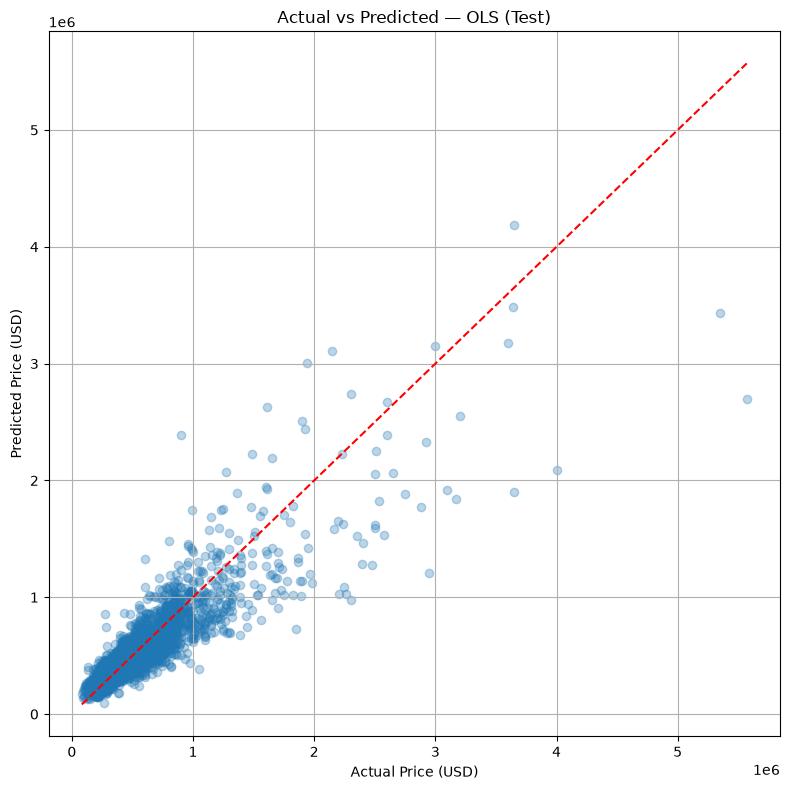

In [188]:
# Actual vs Predicted — Test (price gốc)
plt.figure(figsize=(8, 8))
plt.scatter(y_test_price, test_pred_price, alpha=0.3)
plt.plot([y_test_price.min(), y_test_price.max()],
         [y_test_price.min(), y_test_price.max()], "r--")
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.title("Actual vs Predicted — OLS (Test)")
plt.grid(True)
plt.tight_layout()
plt.show()


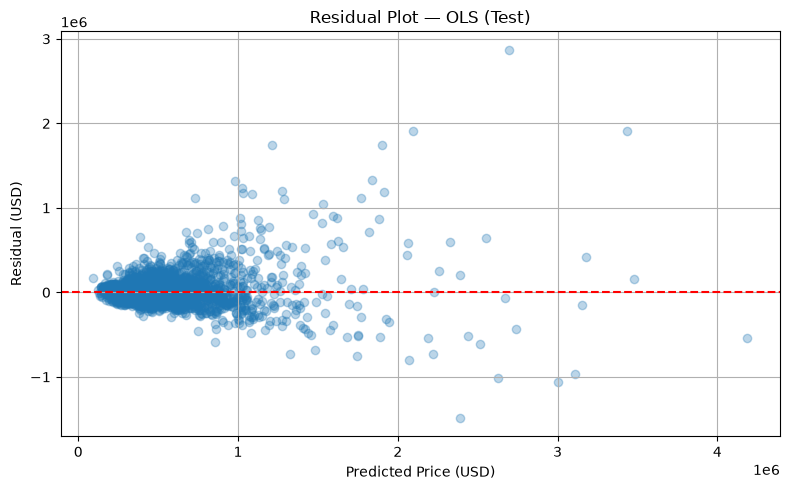

In [189]:
# Residual Plot — Test (price gốc)
residuals = y_test_price - test_pred_price

plt.figure(figsize=(8, 5))
plt.scatter(test_pred_price, residuals, alpha=0.3)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Predicted Price (USD)")
plt.ylabel("Residual (USD)")
plt.title("Residual Plot — OLS (Test)")
plt.grid(True)
plt.tight_layout()
plt.show()
